### Modena CMOS-based HD neural probe hands-on Oct 9th 2026

In this hands-on session, the goal is to extract spiking activity from the raw data acquired with a CMOS-based High Density (HD) SiNAPS neural probe.

For this session, we will specifically rely on a one minute recording of the medial prefrontal cortex (mPFC) in an awake, freely-moving, mouse.

The probe used for this recording is a 256 channel, 1-shank, SiNAPS probe (p256s1) (Angotzi et al., 2019).
The library used for analyzing this recording is SpikeInterface (Buccino et al., 2019), which is a unified framework for processing neural recordings with support for multiple interfaces. For more information: https://spikeinterface.readthedocs.io/en/stable/


Gian Nicola Angotzi, Fabio Boi, Aziliz Lecomte, Ermanno Miele, Mario Malerba, Stefano Zucca, Antonino Casile, Luca Berdondini (2019) SiNAPS: An implantable active pixel sensor CMOS-probe for simultaneous large-scale neural recordings  Biosensors and Bioelectronics Volume 126 Pages 355-364 ISSN 0956-5663

Alessio P Buccino, Cole L Hurwitz, Samuel Garcia, Jeremy Magland, Joshua H Siegle, Roger Hurwitz, Matthias H Hennig (2020) SpikeInterface, a unified framework for spike sorting eLife 9:e61834  

## Step 0. Import all required libraries and download the raw data

---

In [ ]:
!pip install "spikeinterface[full]" ipykernel
print("Libraries install successful!")

# Let's download the dataset (1 min of "raw" recordings) as a HDF5 file
# and unzip it in the local (cloud) storage
!curl -L -o 250113_Chronic_9812_C26_empty_1_Exported_RT_Frames_0_1200000.h5.zip "https://www.dropbox.com/scl/fi/9we4ka1c0xeaok7wgq5d6/250113_Chronic_9812_C26_empty_1_Exported_RT_Frames_0_1200000.h5.zip?rlkey=xcpzseu2edfqweesvmi5g3vpk&dl=1"
!unzip -o 250113_Chronic_9812_C26_empty_1_Exported_RT_Frames_0_1200000.h5.zip
print("Data download successful!")

import spikeinterface as si
import spikeinterface.extractors as se
import matplotlib.pyplot as plt
import numpy as np
import probeinterface as pi
print("Imports successful!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.5/712.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.0/847.0 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.3/462.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 12.1 MB/s eta 0:00:00
   ━━

## Step 1. Initialize the recording

In [ ]:
rec_path = "/content/250113_Chronic_9812_C26_empty_1_Exported_RT_Frames_0_1200000.h5"

# Because we imported spikeinterface.extractors as se, we access the reader through se:
raw_rec = se.read_sinaps_research_platform_h5(rec_path)

raw_rec

SinapsResearchPlatformH5RecordingExtractor: 256 channels - 20.0kHz - 1 segments 
                                            1,200,000 samples - 60.00s (1.00 minutes) - int16 dtype - 585.94 MiB
  file_path: /content/250113_Chronic_9812_C26_empty_1_Exported_RT_Frames_0_1200000.h5

## Step 2. Ensure the probe is linked to the recording

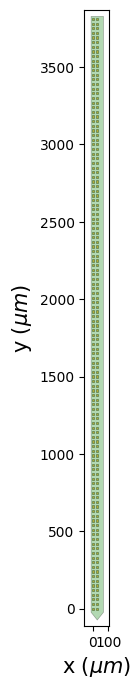

In [ ]:
if not raw_rec.has_probe():
    import probeinterface as pi
    probe = pi.get_probe(
        manufacturer="sinaps-research-platform",
        probe_name="p256s1"
    )
    probe.set_device_channel_indices(probe.contact_ids)
    raw_rec.set_probe(probe)

import spikeinterface.widgets as sw
sw.plot_probe_map(raw_rec, figsize=(6,8))

## Step 3. Let's visualize some of the signal

---

Text(0, 0.5, 'Channel ID')

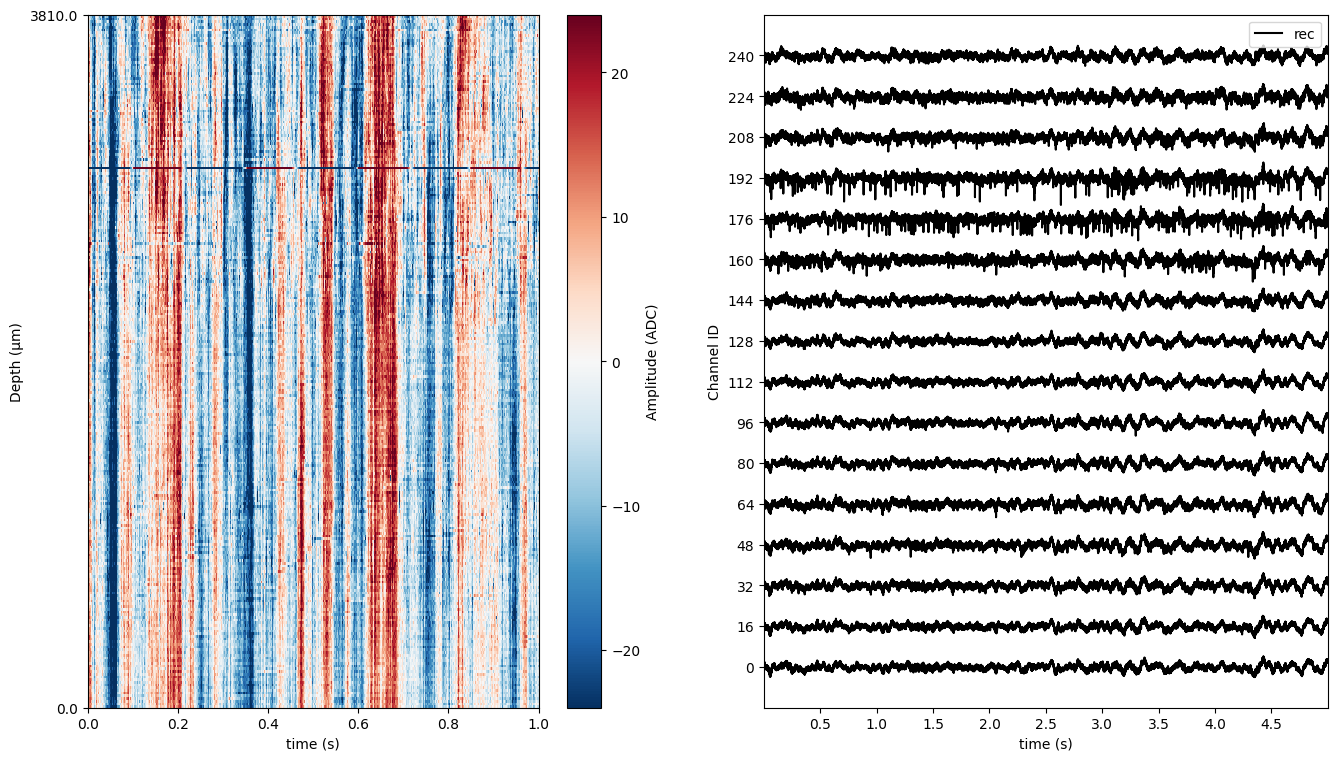

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16,9))

import spikeinterface.widgets as sw

# plot the first second of the recording as a heatmap
scale_colorbar = np.percentile(raw_rec.get_traces(end_frame=raw_rec.sampling_frequency), 99) # set the scale of the heatmap to be the 99th percentile value of the first second (1 * sampling frequency) of the recording
sw.plot_traces(raw_rec, ax=axs[0], clim=(-scale_colorbar, scale_colorbar))
axs[0].set_ylabel("Depth (μm)")
axs[0].set_xlabel("time (s)")
im = axs[0].images[0]
cbar = im.colorbar
cbar.set_label("Amplitude (ADC)")
# plot the first 5 seconds of 16 equally spaced channels
selected_channels_plot = np.arange(start=0, stop=raw_rec.get_num_channels(), step=16)
sw.plot_traces(raw_rec, channel_ids=selected_channels_plot, time_range=[0,5], show_channel_ids=True, ax=axs[1])
axs[1].set_ylabel("Channel ID")

# Step 4. Preprocessing

Let's clean the recording before identifying spikes. The steps that will be used for this example are Channel Masking, Filtering and Artefact/Noise removal.

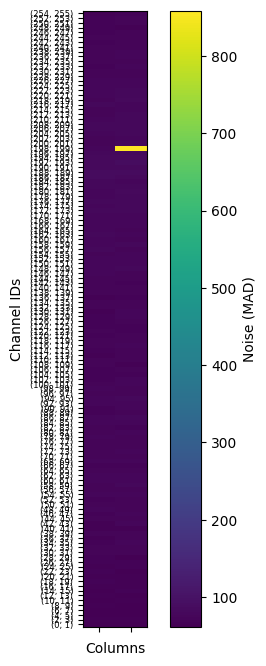

In [ ]:
# There was an odd looking channel in the heatmap that could represent an anomalous channel. Let's calculate the noise and try to identify the channel.

# calculate noise using the median absolute deviation (MAD)
noise = si.get_noise_levels(raw_rec, method="mad")

# plot
noise_reshaped = np.stack((noise[0::2], noise[1::2]), axis=1)
y_ticks = np.arange(noise_reshaped.shape[0])
y_labels = [(2*i, 2*i + 1) for i in y_ticks.tolist()]

plt.figure(figsize=(6,8))
plt.imshow(noise_reshaped, aspect=0.15, origin="lower")
plt.yticks(y_ticks, y_labels, fontsize=6)
plt.ylabel("Channel IDs")
plt.xlabel("Columns")
plt.xticks([0,1], [])
plt.colorbar(label="Noise (MAD)")

199


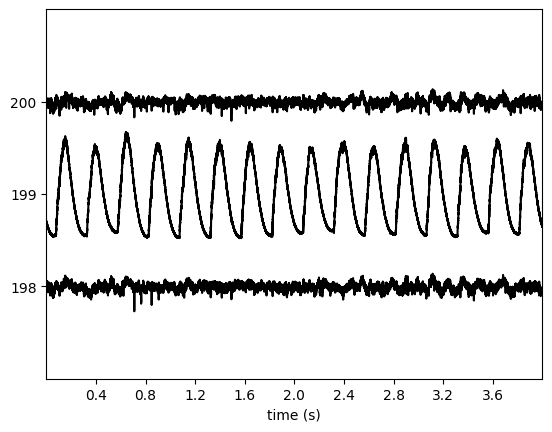

In [ ]:
# lets plot the channel
noisy_ch = noise.argmax()
import spikeinterface.widgets as sw
sw.plot_traces(raw_rec, channel_ids=[noisy_ch-1, noisy_ch, noisy_ch+1], show_channel_ids=True, add_legend=False, time_range=[0,4])
print(noisy_ch)

In [ ]:
# Let's safely remove the channel if it exists in the active recording IDs
if noisy_ch in raw_rec.get_channel_ids():
    rec_preprocessed = raw_rec.remove_channels([noisy_ch])
else:
    print(f"Channel {noisy_ch} is already absent from the recording IDs.")

import spikeinterface.preprocessing as spr

# Apply a bandpass filter to remove low frequency components, and highlight the spiking activity which is isolated to higher frequency bands
rec_preprocessed = spr.bandpass_filter(rec_preprocessed, freq_min=300, freq_max=5000)

# Remove common-mode noise and globally shared artefacts using common referencing
rec_preprocessed = spr.common_reference(rec_preprocessed, operator="median")

Text(0, 0.5, 'Channel ID')

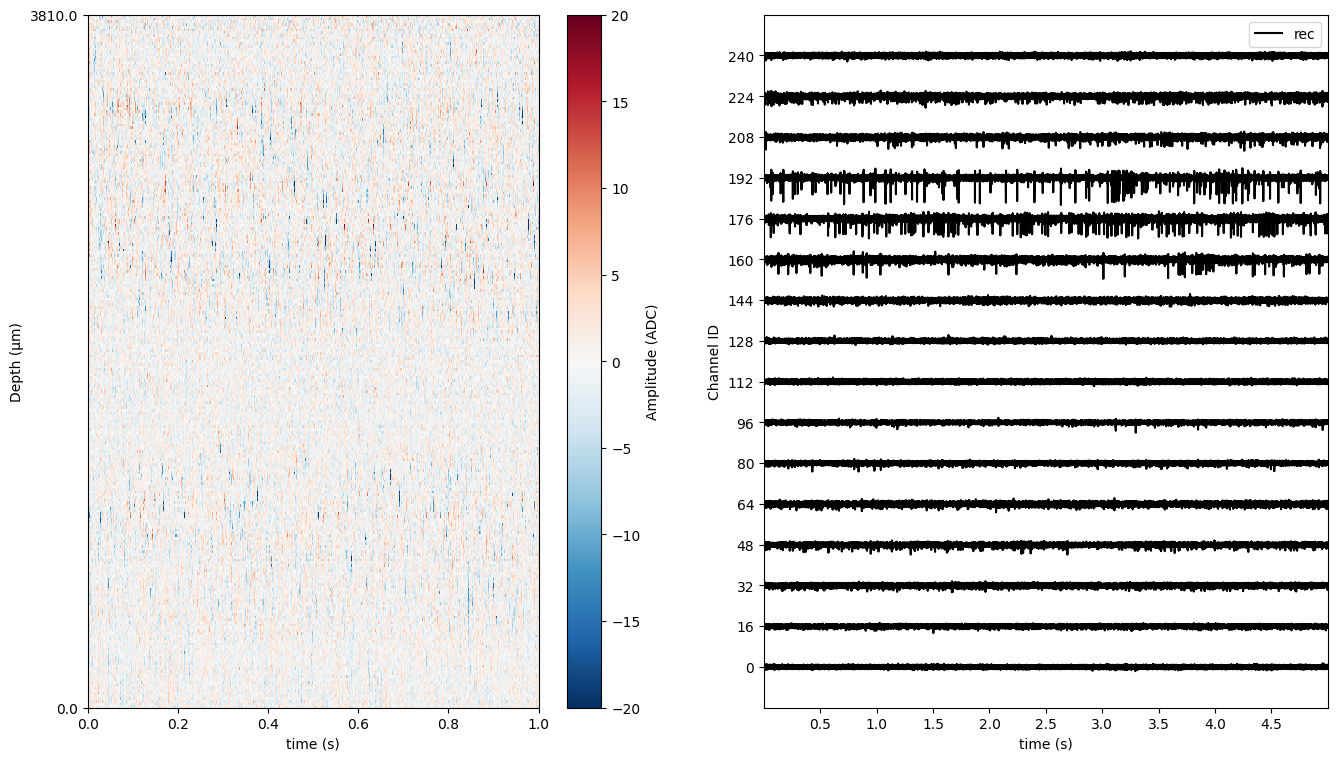

In [ ]:
# let's plot again and see the results
fig, axs = plt.subplots(1, 2, figsize=(16,9))

import spikeinterface.widgets as sw

# same plots, but reduce the scale on the heatmap so we can see the finer details
sw.plot_traces(rec_preprocessed, ax=axs[0], time_range=[0,1], clim=(-20,20))
axs[0].set_ylabel("Depth (μm)")
axs[0].set_xlabel("time (s)")
im = axs[0].images[0]
cbar = im.colorbar
cbar.set_label("Amplitude (ADC)")
sw.plot_traces(rec_preprocessed, channel_ids=selected_channels_plot, time_range=[0,5], show_channel_ids=True, ax=axs[1])
axs[1].set_ylabel("Channel ID")

# Step 5. Let's perform peak detection

### Step 5a. Vectorized Peak Detection for Action Potentials

To identify individual neural firing events, we perform **threshold-based peak detection** on our band-pass filtered signal, common-median referenced recording.

Our detection algorithm works as follows:
1. **Robust Noise Estimation**: We estimate the noise level using the **Median Absolute Deviation (MAD)**. Calculating noise levels using standard deviation can easily be biased by the presence of large spikes; MAD offers a robust, outlier-insensitive baseline.
2. **Thresholding**: We establish an extraction threshold at $-5 \times \text{MAD}$. Any negative voltage deflection below this limit represents a putative spike.
3. **Local Minimum Isolation**: To ensure we only count the absolute center of each action potential, we employ vectorized logic checking that a sample is lower than both its immediate predecessor and successor ($\{x_t < x_{t-1}\} \cap \{x_t < x_{t+1}\}$).

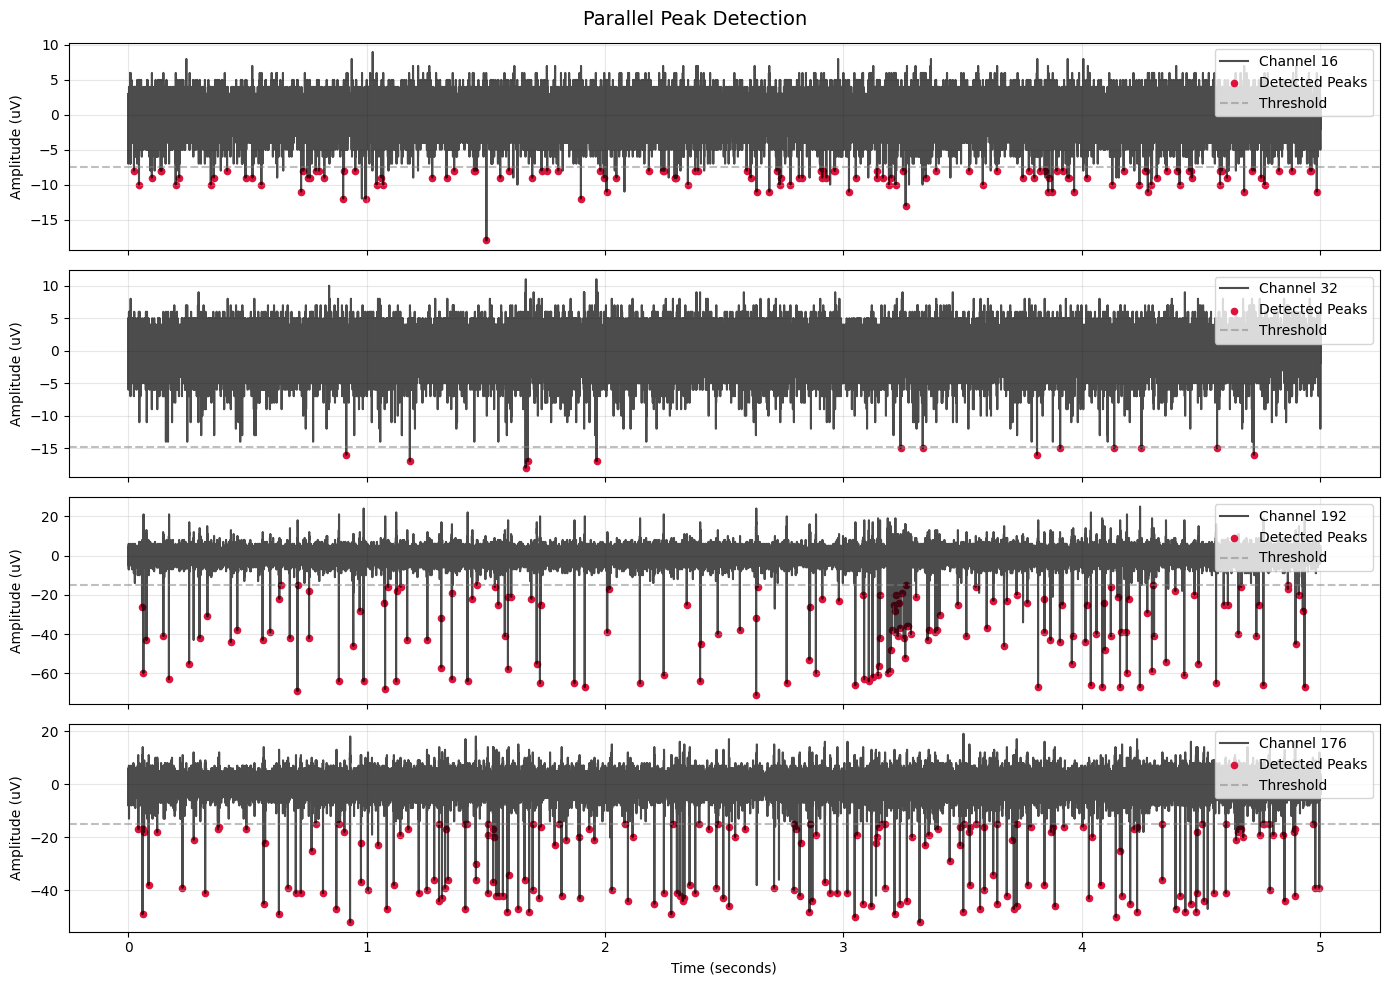

In [ ]:
from multiprocessing import Pool

# 1. Select a subset of channels and retrieve their traces
selected_channels = [16, 32, 192, 176]
channel_indices = [rec_preprocessed.id_to_index(ch) for ch in selected_channels]
sampling_frequency = rec_preprocessed.get_sampling_frequency()

# Extract traces (first 5 seconds: 0 to 100,000 samples)
num_samples = int(5 * sampling_frequency)
traces = rec_preprocessed.get_traces(start_frame=0, end_frame=num_samples, channel_ids=selected_channels)
# 'traces' is a numpy array of shape (num_samples, num_channels)

# 2. Define a peak detection function for a single channel's trace
def detect_peaks_numpy(trace, threshold_factor=5.0):
    """
    Detects local minima below a negative threshold.
    """
    # Calculate a robust threshold using Median Absolute Deviation (MAD)
    mad = np.median(np.abs(trace - np.median(trace))) / 0.6745
    threshold = -threshold_factor * mad

    # Vectorized check: trace must be lower than threshold and a local minimum
    # (lower than its preceding and succeeding samples)
    is_peak = (trace < threshold) & (trace < np.roll(trace, 1)) & (trace < np.roll(trace, -1))

    # Exclude boundary rolling artifacts
    is_peak[0] = False
    is_peak[-1] = False

    # Get indices of the peaks
    peak_indices = np.where(is_peak)[0]
    return peak_indices

# Helper function for multiprocessing
def _parallel_detect(args):
    channel_data, ch_idx = args
    peaks = detect_peaks_numpy(channel_data)
    return ch_idx, peaks

# 3. Perform peak detection in parallel across selected channels using multiprocessing
tasks = [(traces[:, idx], ch) for idx, ch in enumerate(selected_channels)]

with Pool() as pool:
    results = pool.map(_parallel_detect, tasks)

# Store results in a dictionary
channel_peaks = {ch: peaks for ch, peaks in results}

# 4. Plot the traces with detected peaks highlighted
time_axis = np.arange(num_samples) / sampling_frequency
fig, axs = plt.subplots(len(selected_channels), 1, figsize=(14, 10), sharex=True)

for idx, ch in enumerate(selected_channels):
    ax = axs[idx]
    ax.plot(time_axis, traces[:, idx], color='black', alpha=0.7, label=f'Channel {ch}')

    peaks = channel_peaks[ch]
    ax.scatter(time_axis[peaks], traces[peaks, idx], color='crimson', marker='o', s=20, label='Detected Peaks')
    ax.axhline(-5 * (np.median(np.abs(traces[:, idx])) / 0.6745), color='gray', linestyle='--', alpha=0.5, label='Threshold')
    ax.set_ylabel('Amplitude (uV)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axs[-1].set_xlabel('Time (seconds)')
plt.suptitle('Parallel Peak Detection', fontsize=14)
plt.tight_layout()
plt.show()

### Step 5b. Peak-Triggered Waveform Alignment and Overlay

To validate that our detected peaks correspond to genuine biophysical action potentials (rather than high-amplitude noise fluctuations), we extract and overlay the waveforms surrounding each detected peak.

For each identified peak:
1. We capture a temporal window starting **5 ms before** the peak (to capture the pre-hyperpolarization and depolarizing phase) and ending **20 ms after** the peak (to capture the repolarization and after-hyperpolarization refractory periods).
2. We align all individual waveforms at $t = 0\text{ ms}$ (the peak trigger sample).
3. By computing the **mean waveform**, we can easily inspect the characteristic extracellular footprint of cortical action potentials on each channel.

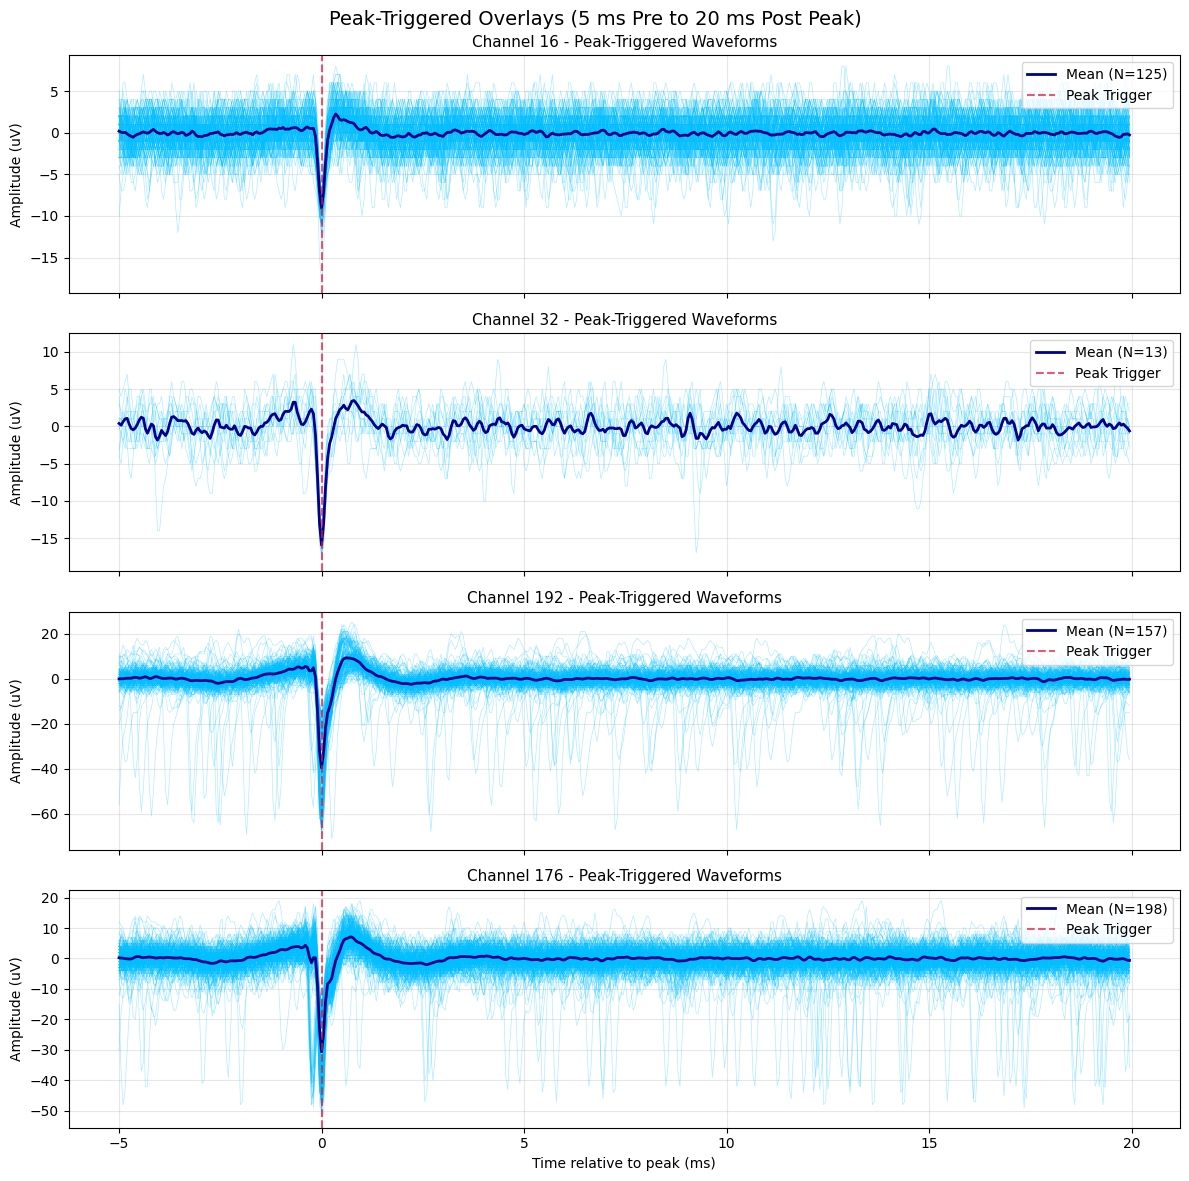

In [ ]:
# Convert milliseconds to samples
fs = rec_preprocessed.get_sampling_frequency()
pre_samples = int(5e-3 * fs)    # 5 ms before (100 samples)
post_samples = int(20e-3 * fs)  # 20 ms after (400 samples)
total_samples = pre_samples + post_samples

# Prepare time vector for plotting relative to peak (t = 0 ms)
time_axis_ms = (np.arange(total_samples) - pre_samples) / fs * 1000

fig, axs = plt.subplots(len(selected_channels), 1, figsize=(12, 12), sharex=True)

for idx, ch in enumerate(selected_channels):
    ax = axs[idx]
    peaks = channel_peaks[ch]
    channel_trace = traces[:, idx]

    waveforms = []
    for peak in peaks:
        # Ensure the peak window lies within our extracted 5-second trace boundary
        if peak - pre_samples >= 0 and peak + post_samples < len(channel_trace):
            wave_window = channel_trace[peak - pre_samples : peak + post_samples]
            waveforms.append(wave_window)

    waveforms = np.array(waveforms)

    if len(waveforms) > 0:
        # Plot individual spike waveforms in a light gray/blue line
        for wave in waveforms:
            ax.plot(time_axis_ms, wave, color='deepskyblue', alpha=0.3, linewidth=0.5)

        # Plot the average spike waveform
        mean_waveform = np.mean(waveforms, axis=0)
        ax.plot(time_axis_ms, mean_waveform, color='darkblue', linewidth=2, label=f'Mean (N={len(waveforms)})')

    ax.axvline(0, color='crimson', linestyle='--', alpha=0.7, label='Peak Trigger')
    ax.set_ylabel('Amplitude (uV)')
    ax.set_title(f'Channel {ch} - Peak-Triggered Waveforms', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axs[-1].set_xlabel('Time relative to peak (ms)')
plt.suptitle('Peak-Triggered Overlays (5 ms Pre to 20 ms Post Peak)', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# Step 6. LFP Analysis

### Step 6a. Extraction of Local Field Potentials (LFP) via Low-Pass Filtering and Downsampling
Local Field Potentials (LFPs) represent the collective synaptic activity of local neuronal populations, containing crucial low-frequency dynamics (< 250-300 Hz). In contrast, extracellular action potentials (spikes) are high-frequency events (300-5000 Hz).

To isolate the LFP from our raw dataset, we apply two main processing steps:

1. **Low-Pass Butterworth Filtering**: A zero-phase forward/backward digital filter (`scipy.signal.filtfilt`) with a 250 Hz cutoff frequency is used to remove spikes and high-frequency noise without introducing phase distortion.
2. **Downsampling (Decimation)**: Since the original sampling frequency is 20,000 Hz, recording low frequencies is highly redundant. We downsample the signal by a factor of 40 (to a 500 Hz sampling rate) to reduce computational overhead and memory footprint while satisfying the Nyquist-Shannon sampling theorem.

In [ ]:
from scipy.signal import butter, filtfilt, welch

# Choose a few channels for LFP analysis
lfp_channels = [16, 32, 192, 176] #[0, 16, 32, 48]
fs_raw = raw_rec.get_sampling_frequency()  # 20,000 Hz

# Extract 10 seconds of raw data (to have a good resolution for PSD)
num_lfp_samples = int(10 * fs_raw)
raw_traces = raw_rec.get_traces(start_frame=0, end_frame=num_lfp_samples, channel_ids=lfp_channels)

# 2. Extract LFP by low-pass filtering (< 300 Hz) and downsampling
def extract_lfp(trace, fs_in, cutoff=300.0, downsample_factor=40):
    # Design a low-pass Butterworth filter
    nyquist = 0.5 * fs_in
    normal_cutoff = cutoff / nyquist
    b, a = butter(N=4, Wn=normal_cutoff, btype='low', analog=False)

    # Apply zero-phase forward/backward filter using scipy/numpy
    filtered_trace = filtfilt(b, a, trace)

    # Downsample by taking every N-th sample (decimation)
    lfp_trace = filtered_trace[::downsample_factor]
    fs_out = fs_in / downsample_factor
    return lfp_trace, fs_out

downsample_factor = 40
fs_lfp = fs_raw / downsample_factor  # 20,000 / 40 = 500 Hz

lfp_data = []
for i in range(len(lfp_channels)):
    lfp_trace, _ = extract_lfp(raw_traces[:, i], fs_raw, cutoff=250.0, downsample_factor=downsample_factor)
    lfp_data.append(lfp_trace)

lfp_data = np.array(lfp_data).T  # Shape: (num_lfp_samples_downsampled, num_channels)

Text(0.5, 1.0, 'FB (2-5000 Hz, fs=20,000 Hz)')

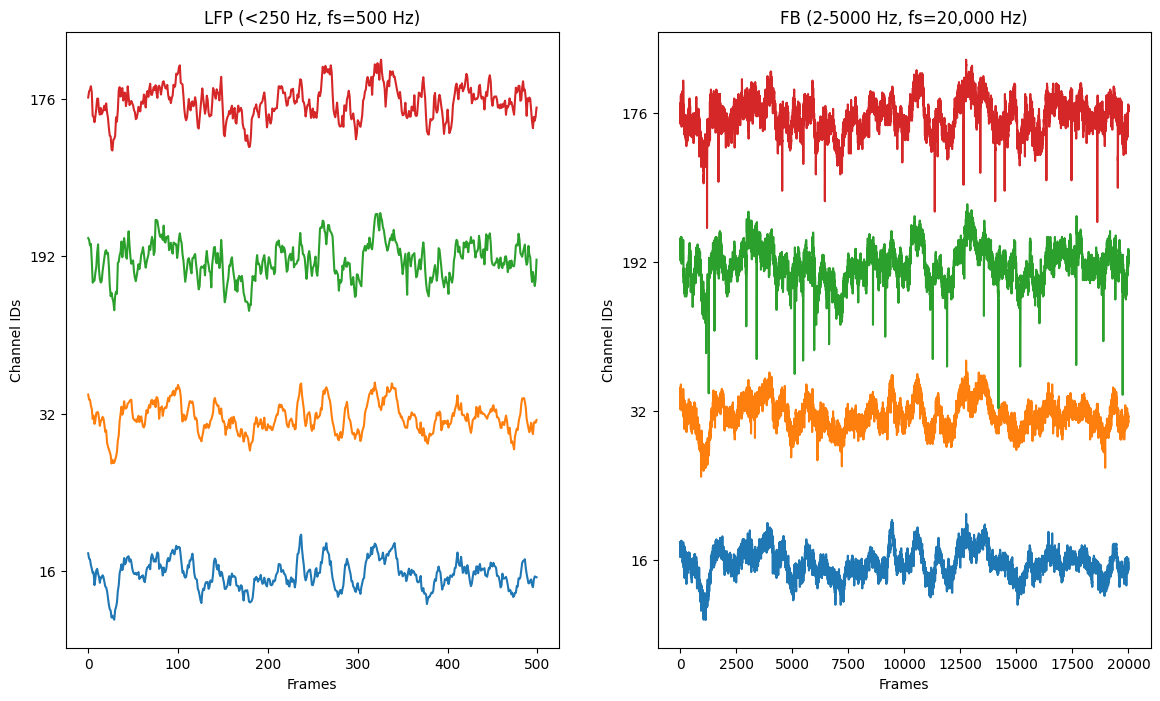

In [ ]:
# Let's compare the LFP channels to the full-band version
fig, (ax_lfp, ax_fb) = plt.subplots(1, 2, figsize=(14,8))

# Plot the first second of the previously visualized channels
plot_data_lfp = lfp_data[:int(fs_lfp), :]
spacing = 100 # scale factor
offsets = np.arange(plot_data_lfp.shape[1]) * spacing
time = np.arange(fs_lfp)
ax_lfp.plot(time, plot_data_lfp + offsets)
ax_lfp.set_yticks(offsets, labels=lfp_channels)
ax_lfp.set_ylabel("Channel IDs")
ax_lfp.set_xlabel("Frames")
ax_lfp.set_title("LFP (<250 Hz, fs=500 Hz)")

plot_data_fb = raw_rec.get_traces(end_frame=1*fs_raw, channel_ids=lfp_channels)
spacing = 100
time_ap = np.arange(fs_raw)
ax_fb.plot(time_ap, plot_data_fb + offsets)
ax_fb.set_yticks(offsets, labels=lfp_channels)
ax_fb.set_ylabel("Channel IDs")
ax_fb.set_xlabel("Frames")
ax_fb.set_title("FB (2-5000 Hz, fs=20,000 Hz)")

### Step 6b. High-Resolution Power Spectral Density (PSD) Analysis

To study steady-state neural oscillations (such as delta, theta, alpha, and beta bands) present in the LFP, we estimate the distribution of signal power over different frequencies.

We utilize the **Welch Periodogram Method** which is a robust estimator of spectral density. By partitioning the LFP signal into overlapping epochs, calculating the Fourier Transform on each window, and averaging the results, it significantly reduces noise compared to a standard periodogram. Here, we implement an 8-second window segment length to yield a highly resolved frequency grid (0.125 Hz resolution), focusing specifically on the $0 - 50\text{ Hz}$ range.

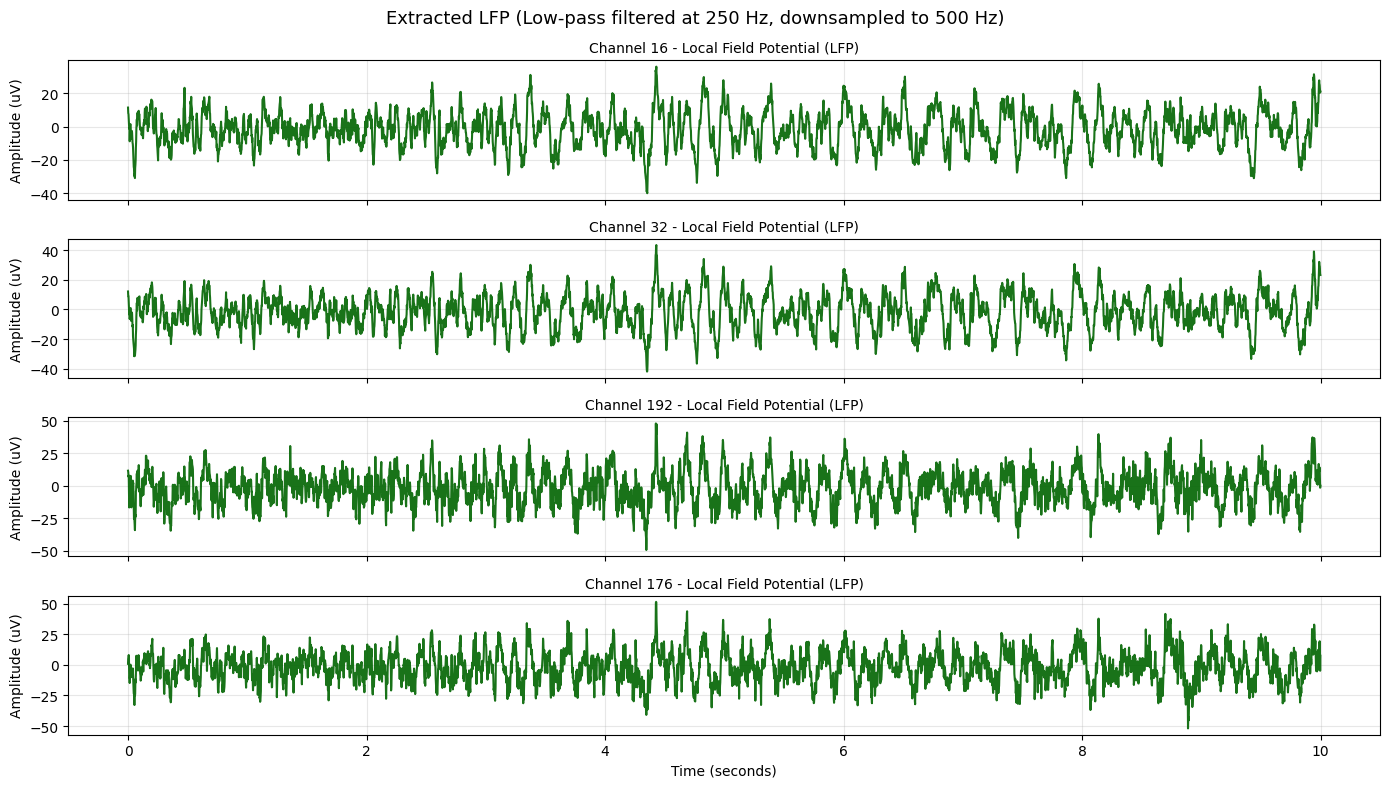

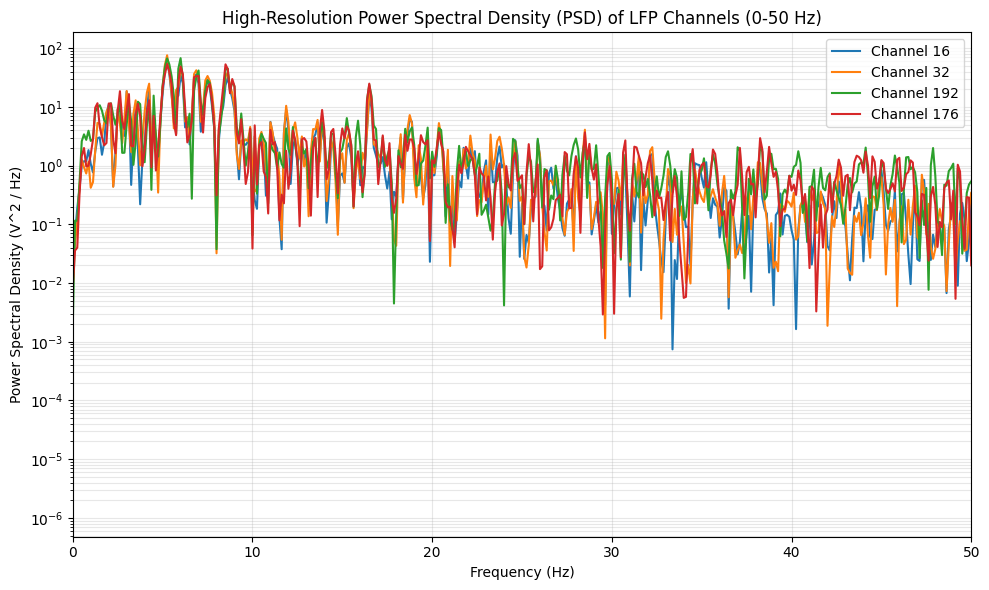

In [ ]:
time_lfp = np.arange(len(lfp_data)) / fs_lfp

# 3. Plot the LFP Traces
fig, axs = plt.subplots(len(lfp_channels), 1, figsize=(14, 8), sharex=True)
for i, ch in enumerate(lfp_channels):
    axs[i].plot(time_lfp, lfp_data[:, i], color='darkgreen', alpha=0.9)
    axs[i].set_ylabel('Amplitude (uV)')
    axs[i].set_title(f'Channel {ch} - Local Field Potential (LFP)', fontsize=10)
    axs[i].grid(True, alpha=0.3)
axs[-1].set_xlabel('Time (seconds)')
plt.suptitle('Extracted LFP (Low-pass filtered at 250 Hz, downsampled to 500 Hz)', fontsize=13)
plt.tight_layout()
plt.show()

# 4. Perform Power Spectral Density (PSD) Analysis using Welch method
plt.figure(figsize=(10, 6))
for i, ch in enumerate(lfp_channels):
    # Calculate PSD with higher resolution: 8-second window (nperseg = fs_lfp * 8)
    # This yields a very high frequency resolution of 1/8 = 0.125 Hz per bin
    frequencies, psd = welch(lfp_data[:, i], fs=fs_lfp, nperseg=int(fs_lfp * 8))

    # Plot PSD in dB
    plt.semilogy(frequencies, psd, label=f'Channel {ch}', linewidth=1.5)

plt.title('High-Resolution Power Spectral Density (PSD) of LFP Channels (0-50 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V^2 / Hz)')
plt.xlim(0, 50)  # Focus specifically on 0 to 50 cycles per second as requested
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Step 6c. Spectrogram (Spectral Run) over the Full Recording Duration

While PSD plots show the average frequency content across a whole session, neural processes are highly dynamic and non-stationary. To capture how the power of low-frequency oscillations evolves over time, we perform a **Spectral Run** (spectrogram) over the full 60-second duration.

Using a moving Fourier transform window, we compute the power spectrum across short temporal segments. We then represent this in a 3D plot (Time vs. Frequency vs. Power in dB) using a color heatmap. This allows us to observe time-varying micro-states and power fluctuations in the $0 - 50\text{ Hz}$ range.

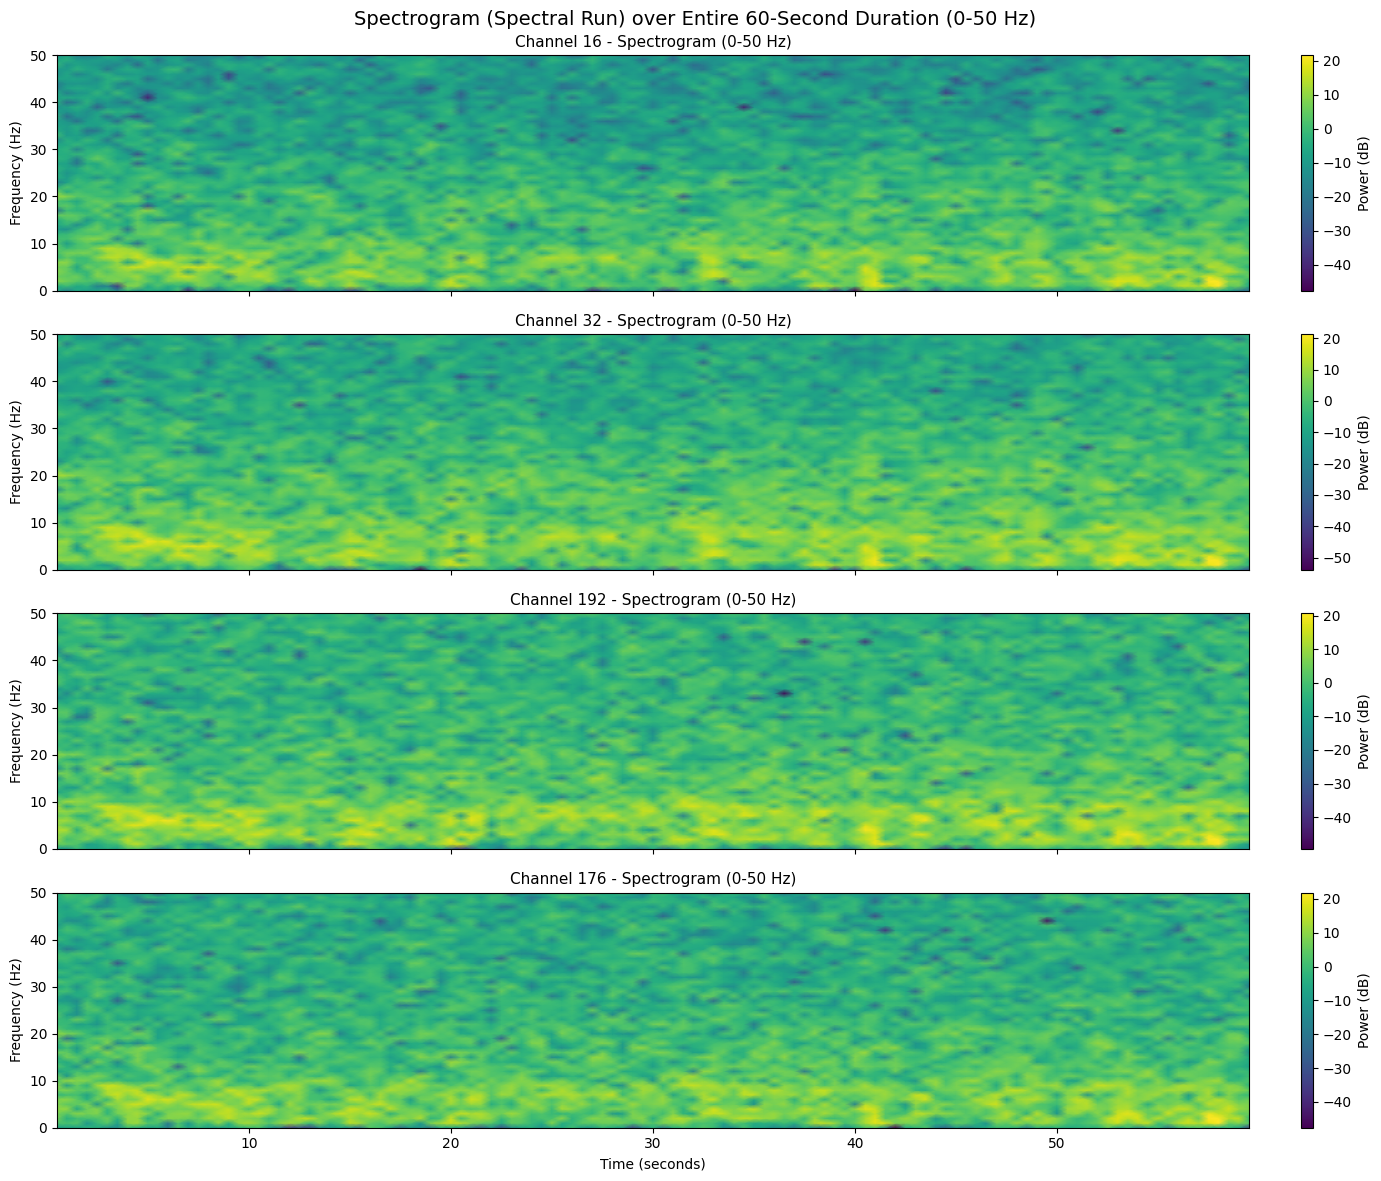

In [ ]:
from scipy.signal import spectrogram

# 1. Retrieve the entire duration (1,200,000 samples) for the selected channels
fs_raw = raw_rec.get_sampling_frequency()
total_samples = raw_rec.get_num_samples()
raw_full_traces = raw_rec.get_traces(start_frame=0, end_frame=total_samples, channel_ids=lfp_channels)

# 2. Compute and plot the spectrogram for each channel
fig, axs = plt.subplots(len(lfp_channels), 1, figsize=(14, 12), sharex=True)

for i, ch in enumerate(lfp_channels):
    # Extract entire trace for this channel
    channel_trace = raw_full_traces[:, i]

    # Compute spectrogram using SciPy
    # nperseg=int(fs_raw) gives a 1-second time window (1 Hz frequency resolution)
    frequencies, times, Sxx = spectrogram(channel_trace, fs=fs_raw, nperseg=int(fs_raw), noverlap=int(fs_raw * 0.5))

    # Plot spectrogram (focusing precisely on low/medium frequencies up to 50 Hz)
    freq_mask = (frequencies >= 0) & (frequencies <= 50)
    Sxx_dB = 10 * np.log10(Sxx[freq_mask, :])

    ax = axs[i]
    im = ax.pcolormesh(times, frequencies[freq_mask], Sxx_dB, shading='gouraud', cmap='viridis')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'Channel {ch} - Spectrogram (0-50 Hz)', fontsize=11)

    # Add a colorbar for each subplot
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Power (dB)')

axs[-1].set_xlabel('Time (seconds)')
plt.suptitle('Spectrogram (Spectral Run) over Entire 60-Second Duration (0-50 Hz)', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# Group Activity

Now that you have learned how to visualize and process data recorded with a CMOS-based high-density neural probe dataset, use the same workflow to explore a different subset of channels (over 250 to choose from!) and test how different processing parameters affect the results.

Working in your group:
1. **Re-visualize the dataset and select 4 new channels** from the 256 available channels that you would like to analyse.
2. **Re-run the analysis and regenerate the plots** for your selected channels
    - Feel free to modify parameters within the code cells and observe how they affect the results.
    - Some parameters include:
      - `threshold_factor` in `detect_peaks_numpy()` (e.g. values between 2.5 and 6)
      - `pre_samples` and `post_samples` in Step 4b
      - Filter settings (e.g. `cutoff`, `freq_min`, `freq_max`)
3. **Calculate metrics on the detected spikes** to assess their characteristics and quality.
    - Possible metrics include:
        - Firing rate
        - Signal-to-noise ratio (SNR)
        - Inter-spike-interval (ISI) violation ratio
        - Median spike amplitude
        - Other you find interesting...
4. **Prepare a short presentation** summarizing your analysis and share your results with the other groups.
    - Include the channels you selected
    - Highlight any parameters you changed
    - Show the most informative plots
    - Report the metrics you calculated
    - Discuss what you observed and anything you found interesting


Some useful references for the quality metrics:
- https://spikeinterface.readthedocs.io/en/stable/modules/metrics/qualitymetrics/firing_rate.html
- https://alleninstitute.github.io/openscope_databook/visualize-unit-metrics/
- LLMs such as Gemini can also be used as support